# ARTL: Outlier-Robust Neural Network Training
Okuno and Yagishita (2026+)

In [1]:
!pip install -q git+https://github.com/oknakfm/artl-torch.git

  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR
from artl import ARTLTrainer, make_checkered, make_stripe

print('device:', 'cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device: cuda


## Model specification (MLP)

In [3]:
HIDDEN  = 100
NLAYERS = 4

def build_mlp():
    """Sigmoid MLP"""
    layers, in_dim = [], 2
    for _ in range(NLAYERS):
        layers += [nn.Linear(in_dim, HIDDEN), nn.Sigmoid()]
        in_dim = HIDDEN
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

print(f'MLP: 2 → ({HIDDEN} × Sigmoid) × {NLAYERS} → 1')
print(f'#Parameters: {sum(p.numel() for p in build_mlp().parameters()):,}')

MLP: 2 → (100 × Sigmoid) × 4 → 1
#Parameters: 30,701


## Dataset generation

In [4]:
N_GRID       = 15       # number of grids
OUTLIER_RATE = 0.03     # outlier rate
OUTLIER_VAL  = 7.5      # outlier value (as y_out)
DOMAIN       = (-np.pi, np.pi)

datasets = [
    ('Checkered',
     r'$f^*(x)=\sin(2x_1)\cos(2x_2)$',
     make_checkered(n_grid=N_GRID, domain=DOMAIN,
                    outlier_rate=OUTLIER_RATE, outlier_value=OUTLIER_VAL,
                    seed=SEED)),
    ('Stripe',
     r'$f^*(x)=\sin(2(x_1+x_2))$',
     make_stripe(n_grid=N_GRID, domain=DOMAIN,
                 outlier_rate=OUTLIER_RATE, outlier_value=OUTLIER_VAL,
                 seed=SEED)),
]

for name, _, d in datasets:
    n = len(d['y_train'])
    print(f'{name:12s}: train={n}, outliers={len(d["out_idx"])} '
          f'({len(d["out_idx"])/n*100:.0f}%),  test={len(d["y_test"])}')

Checkered   : train=225, outliers=7 (3%),  test=10000
Stripe      : train=225, outliers=7 (3%),  test=10000


## NN training using ARTL

In [5]:
results = []

for name, formula, data in datasets:
    print(f'\n{"="*50}')
    print(f'  {name}  {formula}')
    print(f'{"="*50}')

    trainer = ARTLTrainer(
        model        = build_mlp(),
        h            = 0.95,         # inlier rate
        lam          = 1e-5,        # HOVR regularization coefficient
        k            = 3,           # k in HOVR
        q            = 2,           # q in HOVR
        domain_lb    = DOMAIN[0],
        domain_ub    = DOMAIN[1],
        n_mc         = 10,          # sample size for HOVR
        lr           = 1e-2,        # learning rate (initial)
        n_epochs     = 4000,        # number of epochs
        lr_scheduler = lambda opt: StepLR(opt, step_size=1000, gamma=0.7),
        verbose      = 500,
        random_state = SEED,
    )
    trainer.fit(data['X_train'], data['y_train'])

    pmse = trainer.score(data['X_test'], data['y_test'])
    print(f'  → Predictive MSE: {pmse:.4f}')
    results.append((name, formula, data, trainer, pmse))


  Checkered  $f^*(x)=\sin(2x_1)\cos(2x_2)$
[ 500/4000] loss=0.3933  data=0.3087  trim=0.0785  hovr(stochastic)=0.0060
[1000/4000] loss=0.0910  data=0.0558  trim=0.0316  hovr(stochastic)=0.0036
[1500/4000] loss=0.0418  data=0.0180  trim=0.0142  hovr(stochastic)=0.0097
[2000/4000] loss=0.0260  data=0.0110  trim=0.0098  hovr(stochastic)=0.0052
[2500/4000] loss=0.0263  data=0.0093  trim=0.0081  hovr(stochastic)=0.0089
[3000/4000] loss=0.0220  data=0.0076  trim=0.0077  hovr(stochastic)=0.0067
[3500/4000] loss=0.0172  data=0.0070  trim=0.0065  hovr(stochastic)=0.0036
[4000/4000] loss=0.0233  data=0.0065  trim=0.0061  hovr(stochastic)=0.0107
  → Predictive MSE: 0.0210

  Stripe  $f^*(x)=\sin(2(x_1+x_2))$
[ 500/4000] loss=0.5296  data=0.3927  trim=0.1335  hovr(stochastic)=0.0034
[1000/4000] loss=0.1343  data=0.0742  trim=0.0510  hovr(stochastic)=0.0092
[1500/4000] loss=0.0435  data=0.0172  trim=0.0115  hovr(stochastic)=0.0148
[2000/4000] loss=0.0275  data=0.0120  trim=0.0086  hovr(stochastic)

## Visualization（True vs ARTL）

Figure saved → artl_results.png


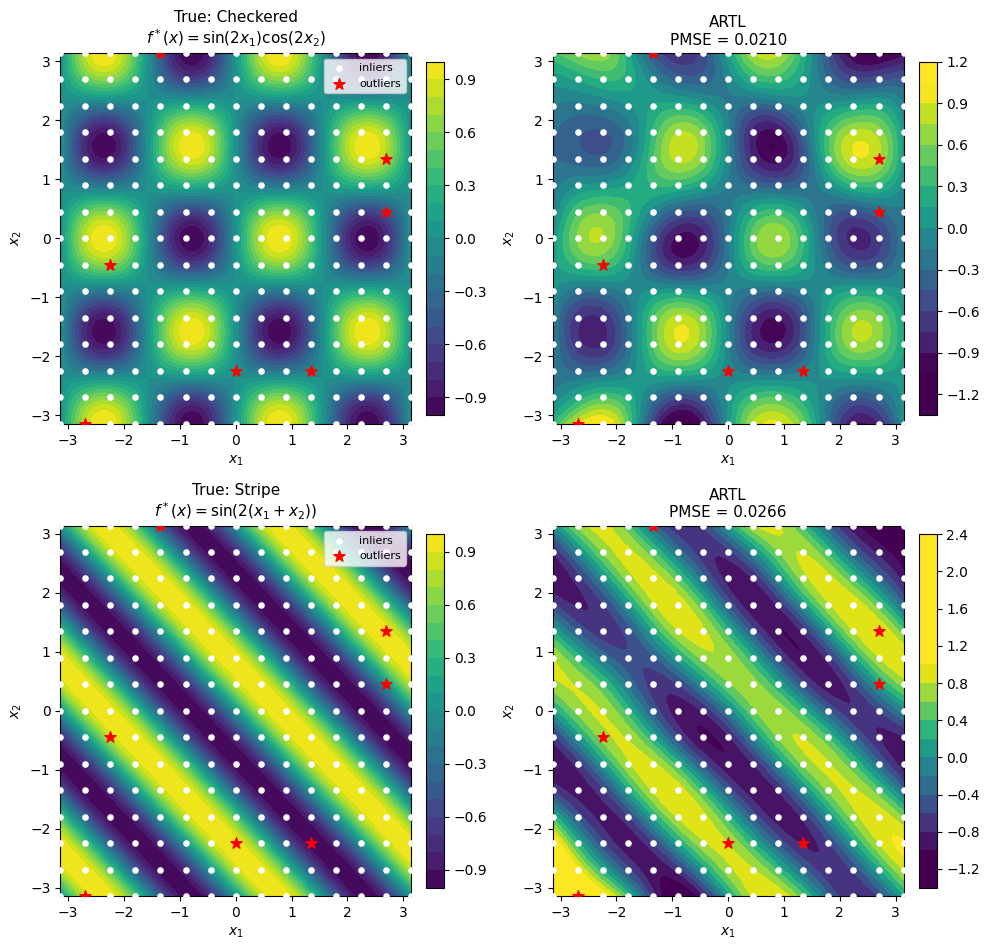

In [6]:
RES = 100
g = np.linspace(*DOMAIN, RES)
G1, G2 = np.meshgrid(g, g)
X_grid = np.column_stack([G1.ravel(), G2.ravel()])

fig, axes = plt.subplots(len(results), 2,
                         figsize=(10, 4.8 * len(results)))

for row, (name, formula, data, trainer, pmse) in enumerate(results):
    Z_true = data['true_fn'](X_grid).reshape(RES, RES)
    Z_artl = trainer.predict(X_grid).reshape(RES, RES)

    vmin, vmax = float(Z_true.min()), float(Z_true.max())
    kw = dict(levels=20, cmap='viridis', vmin=vmin, vmax=vmax)

    X_tr = data['X_train']
    out_idx = data['out_idx']
    inlier = np.ones(len(X_tr), dtype=bool)
    inlier[out_idx] = False

    for col, (Z, title) in enumerate([
        (Z_true, f'True: {name}\n{formula}'),
        (Z_artl, f'ARTL\nPMSE = {pmse:.4f}'),
    ]):
        ax = axes[row, col]
        c = ax.contourf(G1, G2, Z, **kw)
        plt.colorbar(c, ax=ax, fraction=0.046, pad=0.04)
        ax.scatter(X_tr[inlier, 0], X_tr[inlier, 1],
                   c='white', s=14, zorder=5, label='inliers')
        ax.scatter(X_tr[out_idx, 0], X_tr[out_idx, 1],
                   c='red', s=70, marker='*', zorder=6, label='outliers')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
        if col == 0:
            ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('artl_results.png', dpi=130, bbox_inches='tight')
print('Figure saved → artl_results.png')
plt.show()